# Customer Review Sentiment EDA

In [122]:
# any necessary libarires
import nltk
from nltk.corpus import stopwords
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.feature_extraction.text import TfidfVectorizer
st = nltk.PorterStemmer()
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud

### Train Data

In [76]:
# read the train data into two columns 
# one column for sentiment '(+1 or -1)' and another column for the text review
reviews_df_train = pd.read_fwf('traindata.txt', delimiter='\t',sep = '\n',names=["sentiment","review"])

In [77]:
# display a few records from the data frame
reviews_df_train.head(-1)
# looks like there could be format issues for the sentiments 

,sentiment,review
0,1.,This book is such a life saver. It has been s...
1,- 1,I bought this for the leak side when I stay ho...
2,1.,"We live in a windy and cold town, and the wind..."
3,- 1,My baby loves eating different kinds of snacks...
4,- 1,I bought this to replace our Planet Wise bag a...
...,...,...
18500,1.,Color was just what I was looking for but the ...
18501,1.,The negative comments on these gates have a fe...
18502,1.,"This is loads of fun, handles on the side so s..."
18503,1.,This is great! It's so much nicer than the har...


In [78]:
# make sure the last review was also captured 
reviews_df_train[18505:]

,sentiment,review
18505,- 1,"I have not tried the bottles yet, but I just r..."


In [79]:
# get information on the dataframe
reviews_df_train.info()
# there are 9 records with null data in the reviews column

<class 'pandas.DataFrame'>
RangeIndex: 18506 entries, 0 to 18505
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentiment  18506 non-null  str  
 1   review     18497 non-null  str  
dtypes: str(2)
memory usage: 289.3 KB


In [80]:
# get more informatoin on the data frame
reviews_df_train.describe()
# there are 3 unique values for the sentiment, should be only two unique values 

,sentiment,review
count,18506,18497
unique,3,18497
top,1.,This book is such a life saver. It has been s...
freq,9996,1


In [81]:
# check what all the unique values are
reviews_df_train['sentiment'].unique()
# there are two instances of 1 
# assume both should be +1 

<StringArray>
['1. ', '- 1', '1']
Length: 3, dtype: str

In [82]:
# check where all the '1' occure 
reviews_df_train[reviews_df_train['sentiment']=='1']['sentiment']

221     1
3421    1
5021    1
5386    1
Name: sentiment, dtype: str

In [83]:
# further explore the data
reviews_df_train.groupby('sentiment').describe()
# looks like there are no reivews for when sentiment is '1'

review                                                               
           count unique                                                top freq
sentiment                                                                      
- 1         8501   8501  I bought this for the leak side when I stay ho...    1
1              0      0                                                NaN  NaN
1.          9996   9996  This book is such a life saver.  It has been s...    1

In [84]:
# check all reivew values for when sentiment is '1'
reviews_df_train[reviews_df_train['sentiment']=='1']['review']
# reviews are all NaN

221     NaN
3421    NaN
5021    NaN
5386    NaN
Name: review, dtype: str

In [85]:
# remove all the rows where there are na 
reviews_df_train = reviews_df_train.dropna()
reviews_df_train = reviews_df_train.reset_index(drop=True)

In [86]:
# get info on the new data frame
reviews_df_train.info()
# all nulls are now removed 

<class 'pandas.DataFrame'>
RangeIndex: 18497 entries, 0 to 18496
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentiment  18497 non-null  str  
 1   review     18497 non-null  str  
dtypes: str(2)
memory usage: 289.1 KB


In [87]:
# check more info on the new data frame
reviews_df_train.groupby('sentiment').describe()

review                                                               
           count unique                                                top freq
sentiment                                                                      
- 1         8501   8501  I bought this for the leak side when I stay ho...    1
1.          9996   9996  This book is such a life saver.  It has been s...    1

In [88]:
reviews_df_train = reviews_df_train.dropna().reset_index(drop=True)
reviews_df_train.loc[[221, 3421, 5021, 5386], 'review'] = "+1"
reviews_df_train['sentiment'] = reviews_df_train['sentiment'].str.replace('1. ', '+1', regex=False)
reviews_df_train['sentiment'] = reviews_df_train['sentiment'].str.replace('- 1','-1', regex=False)

In [89]:
# check the data type of the columns in the data frame
display(reviews_df_train.dtypes)

sentiment    str
review       str
dtype: object

### Test Data

In [90]:
# read the test data into one columns called test_reviews 
reviews_df_test = pd.read_fwf('testdata.txt', delimiter='\t',sep = '\n',skip_blank_lines=False, names=["test_review"])

In [91]:
# get info on the test data
reviews_df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 18506 entries, 0 to 18505
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   test_review  18497 non-null  str  
dtypes: str(1)
memory usage: 144.7 KB


In [92]:
# check a few records within the test data
reviews_df_test.head(-1)

,test_review
0,Perfect for new parents. We were able to keep ...
1,Helps me know exactly how my babies day has go...
2,I wanted an alternative to printing out daily ...
3,My 3 month old son spend half of his days with...
4,The Baby Tracker brand books are the absolute ...
...,...
18500,Not a big fan of this car seat for a few reaso...
18501,"WTF. The pieces don't fit together, the instru..."
18502,I've gone through a couple of video baby monit...
18503,This monitor is cheap and doesn't work well. O...


In [93]:
# make sure the last review in the test data was captured 
reviews_df_test[18505:]

,test_review
18505,"Short story, I was very disappointed with the ..."


In [94]:
# get the index of all rows where there are no reviews 
reviews_df_test.index[reviews_df_test.isnull().all(1)]
# looks like there are also 9 rows with no reviews 

/var/folders/pw/c5lt31dn1hd6nbdzt8c0lj6r0000gn/T/ipykernel_84958/2004213105.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of all will be keyword-only.
  reviews_df_test.index[reviews_df_test.isnull().all(1)]


Index([200, 341, 8174, 10933, 12965, 14399, 14837, 16781, 16836], dtype='int64')

In [95]:
# replace the null values with "No Review"
reviews_df_test.fillna("No Review", inplace=True)

,test_review
0,Perfect for new parents. We were able to keep ...
1,Helps me know exactly how my babies day has go...
2,I wanted an alternative to printing out daily ...
3,My 3 month old son spend half of his days with...
4,The Baby Tracker brand books are the absolute ...
...,...
18501,"WTF. The pieces don't fit together, the instru..."
18502,I've gone through a couple of video baby monit...
18503,This monitor is cheap and doesn't work well. O...
18504,"These monitors do not work at all, I even atte..."


In [96]:
# get some info on the test data 
reviews_df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 18506 entries, 0 to 18505
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   test_review  18506 non-null  str  
dtypes: str(1)
memory usage: 144.7 KB


### Text Processing

In [97]:
stemmer = st
stop_words = set(stopwords.words("english"))


def clean_text(text):
    """
    Basic NLP preprocessing for visualization and modeling.
    """

    # lowercase
    text = text.lower()

    # remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [98]:
# get few reviews from the original train data 
reviews_df_train['review'].head()

0    This book is such a life saver.  It has been s...
1    I bought this for the leak side when I stay ho...
2    We live in a windy and cold town, and the wind...
3    My baby loves eating different kinds of snacks...
4    I bought this to replace our Planet Wise bag a...
Name: review, dtype: str

In [99]:
# # apply the process_text function on a few rows of the train data 
# reviews_df_train['review'].head().apply(process_text)
# # the function is working properly 

In [102]:
clean_reviews = [clean_text(r) for r in reviews_df_train['review']]

In [105]:
clean_reviews[0:5]

['book life saver helpful able go back track trends answer pediatrician questions communicate different times night newborn think one things everyone required leave hospital went pages newborn version moved infant version finish second infant book third total right baby turns see things must haves baby',
 'bought leak side stay home shape weird doesnt stay breast well hard shell soft one hoped put bra feels hot took milk still spill lost purposei recommend disposable pads works better',
 'live windy cold town wind always blowing sons blanket well bulky annoying perfectly fit chicco keyfit seat zips kept warm throughout rainsnow',
 'baby loves eating different kinds snacks thought snack dispenser great idea wrong heres lid difficult open dispenser bottle kind deep compartment narrow making hard grab snacks compartment half full also worth mentioning small opening lid useless much trouble using dispenser instead use small zip lock bags im thinking using regular containers well',
 'bought

# Visualizations

## Sentiment Distribution (Class Balance)

In [107]:
def plot_sentiment_distribution(labels):

    plt.figure(figsize=(6,4))

    sns.countplot(x=labels)

    plt.title("Sentiment Distribution")

    plt.xlabel("Sentiment")

    plt.ylabel("Count")

    plt.xticks([0,1],["Negative","Positive"])

    plt.show()

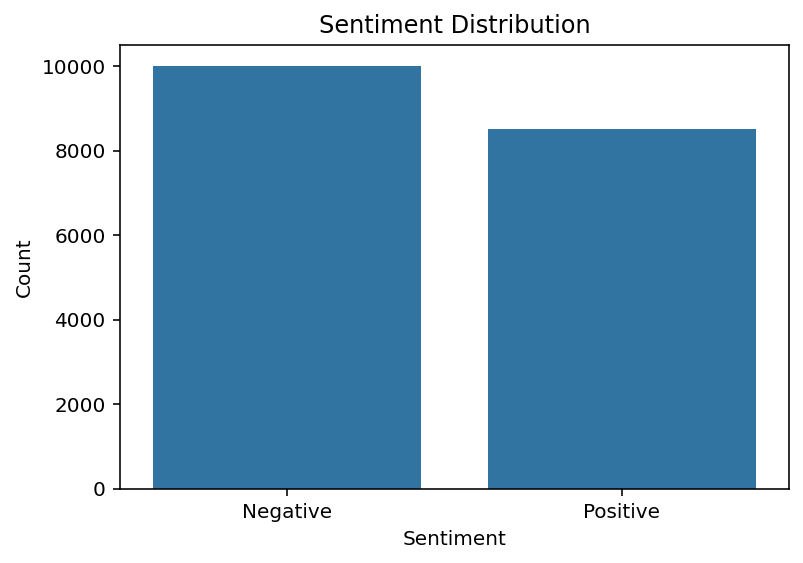

In [111]:
plot_sentiment_distribution(reviews_df_train['sentiment'])

## Word Frequency Bar Chart

In [112]:
def plot_top_words(texts, n=20):

    words = " ".join(texts).split()

    counter = Counter(words)

    common = counter.most_common(n)

    words = [w[0] for w in common]
    counts = [w[1] for w in common]

    plt.figure(figsize=(10,5))

    sns.barplot(x=counts, y=words)

    plt.title("Top Most Frequent Words")

    plt.xlabel("Frequency")

    plt.ylabel("Words")

    plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


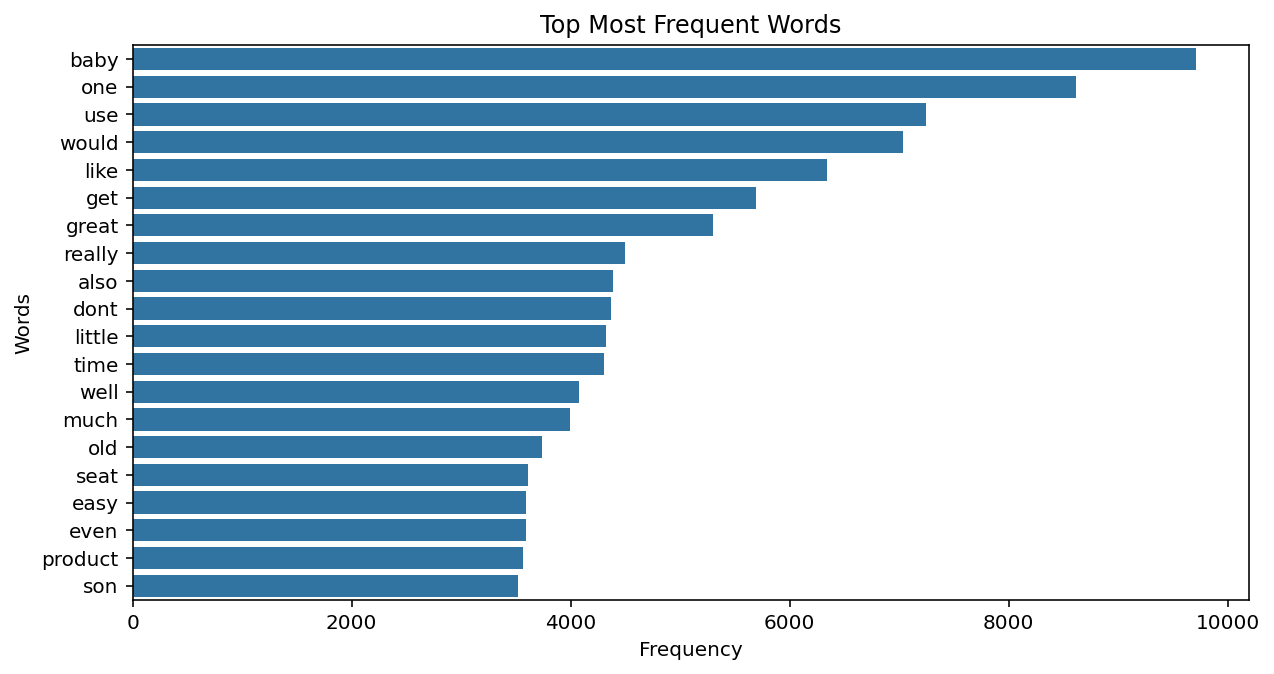

In [113]:
plot_top_words(clean_reviews)

### Positive vs Negative Word Frequency

In [132]:
def plot_sentiment_word_frequency(texts, labels):
    texts = pd.Series(texts)  
    
    positive_text = texts[labels == '+1']
    negative_text = texts[labels == '-1']

    pos_words = Counter(" ".join(positive_text).split())
    neg_words = Counter(" ".join(negative_text).split())

    pos_common = pos_words.most_common(15)
    neg_common = neg_words.most_common(15)

    pos_words = [w[0] for w in pos_common]
    pos_counts = [w[1] for w in pos_common]

    neg_words = [w[0] for w in neg_common]
    neg_counts = [w[1] for w in neg_common]

    fig, axes = plt.subplots(1,2, figsize=(14,6))

    sns.barplot(x=pos_counts, y=pos_words, ax=axes[0])
    axes[0].set_title("Top Positive Words")

    sns.barplot(x=neg_counts, y=neg_words, ax=axes[1])
    axes[1].set_title("Top Negative Words")

    plt.show()

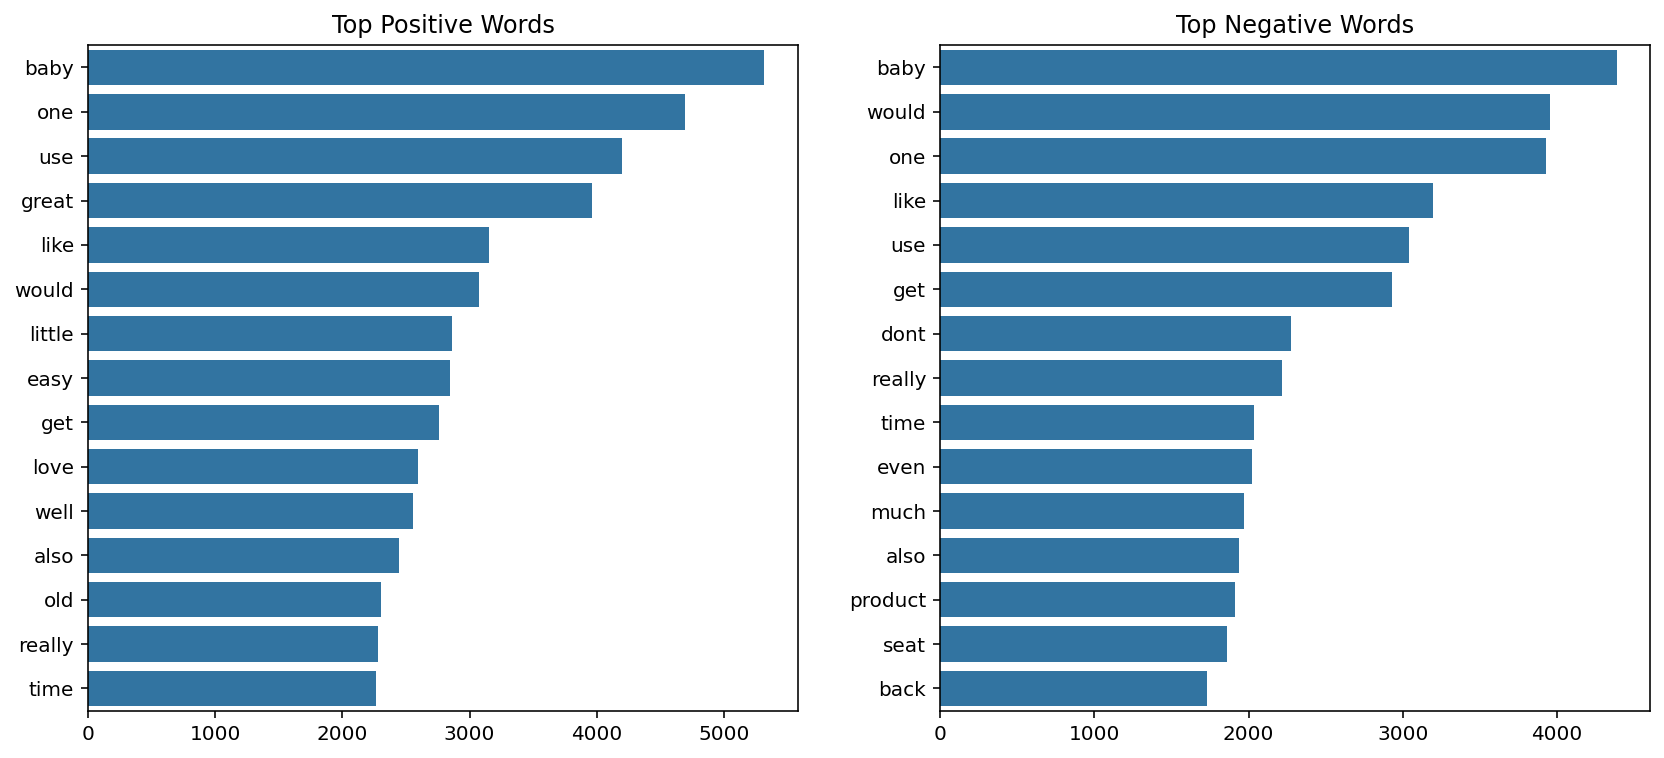

In [133]:
plot_sentiment_word_frequency(clean_reviews, reviews_df_train['sentiment'])

## Word Cloud Visualization

In [123]:
def plot_wordcloud(texts):

    text = " ".join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(12,6))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title("Word Cloud")

    plt.show()

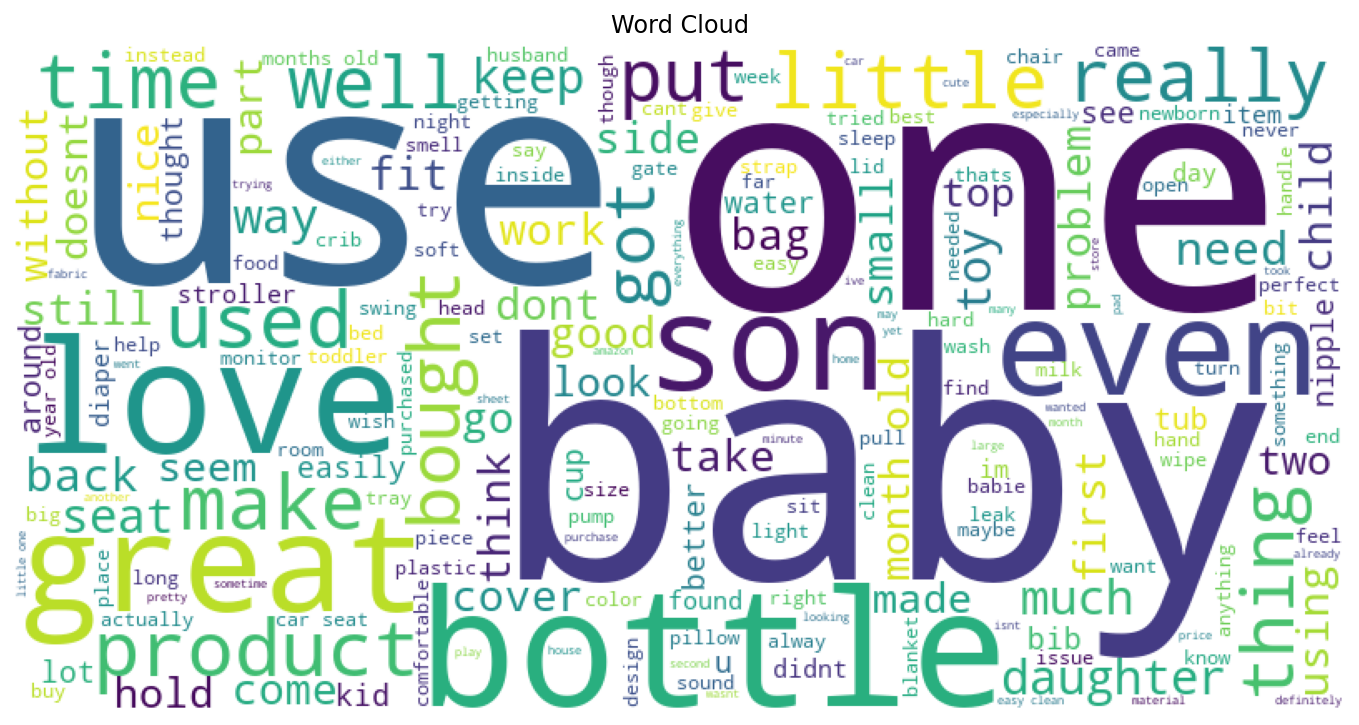

In [124]:
plot_wordcloud(clean_reviews)

## Positive vs Negative Word Clouds

In [137]:
def plot_sentiment_wordcloud(texts, labels):
    texts = pd.Series(texts)  
    
    pos_text = " ".join(texts[labels == '+1'])
    neg_text = " ".join(texts[labels == '-1'])

    pos_wc = WordCloud(width=800, height=400).generate(pos_text)
    neg_wc = WordCloud(width=800, height=400).generate(neg_text)

    fig, axes = plt.subplots(1,2, figsize=(14,6))

    axes[0].imshow(pos_wc)
    axes[0].axis("off")
    axes[0].set_title("Positive Reviews")

    axes[1].imshow(neg_wc)
    axes[1].axis("off")
    axes[1].set_title("Negative Reviews")

    plt.show()

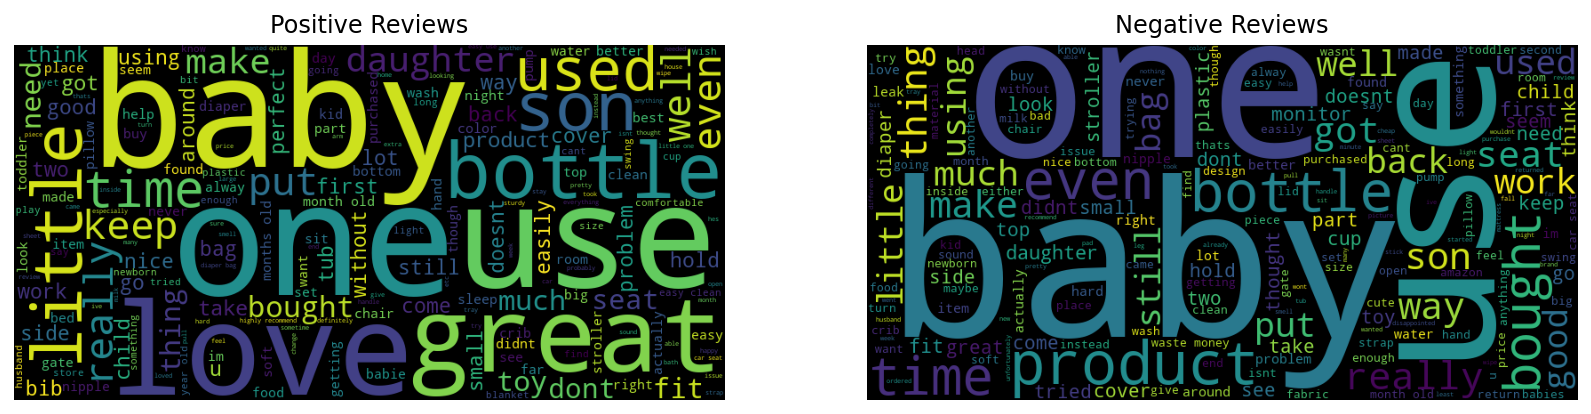

In [138]:
plot_sentiment_wordcloud(clean_reviews, reviews_df_train['sentiment'])

## Review Length Distribution

In [125]:
def plot_review_length_distribution(texts):

    lengths = [len(t.split()) for t in texts]

    plt.figure(figsize=(8,5))

    sns.histplot(lengths, bins=50)

    plt.title("Review Length Distribution")

    plt.xlabel("Number of Words")

    plt.ylabel("Frequency")

    plt.show()

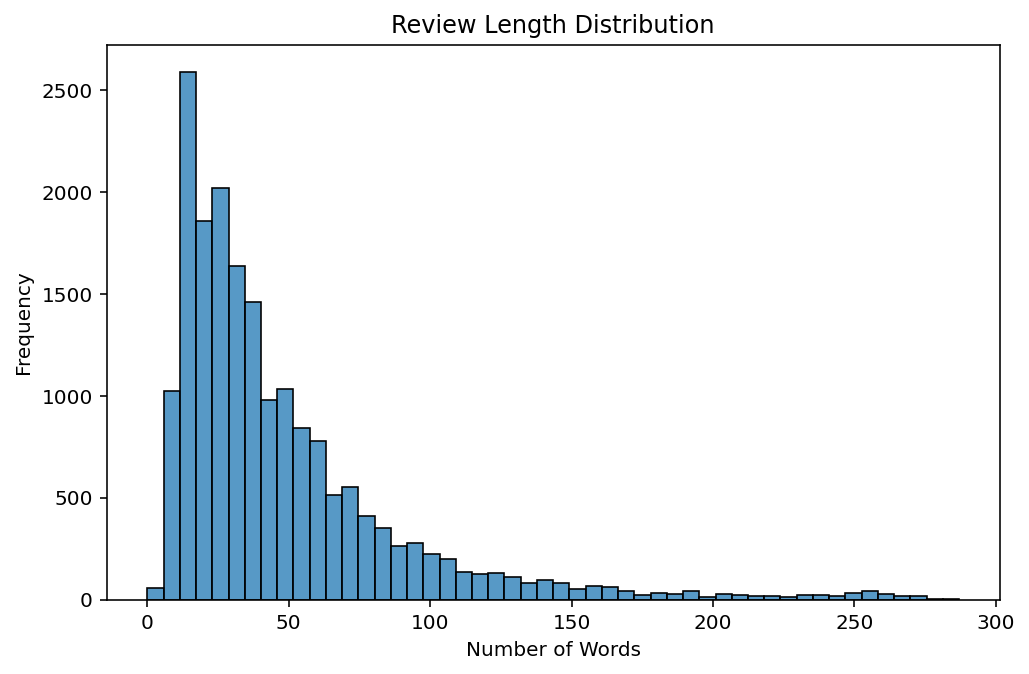

In [126]:
plot_review_length_distribution(clean_reviews)

## TF-IDF Feature Importance

In [127]:
def plot_top_tfidf_features(vectorizer, X_vec, n=20):

    feature_names = vectorizer.get_feature_names_out()

    scores = X_vec.mean(axis=0).A1

    top_idx = scores.argsort()[-n:]

    words = feature_names[top_idx]
    values = scores[top_idx]

    plt.figure(figsize=(10,5))

    sns.barplot(x=values, y=words)

    plt.title("Top TF-IDF Features")

    plt.show()

In [140]:
# using unigrams + bigrams
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),   # unigrams + bigrams
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(clean_reviews)

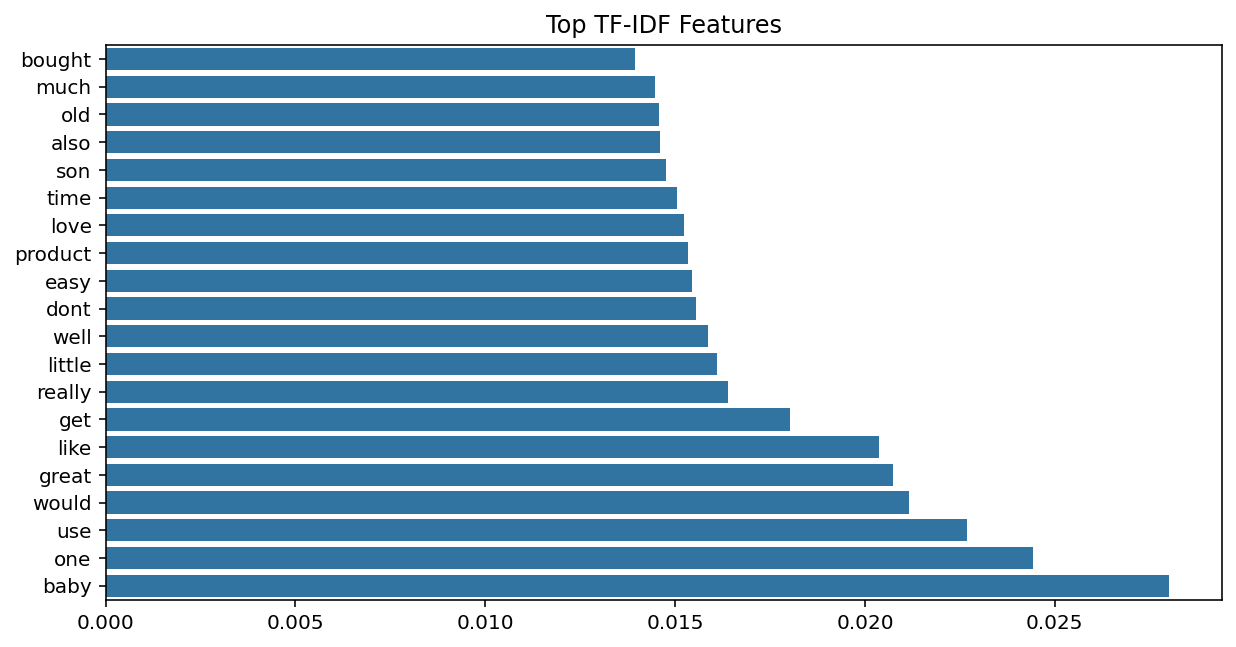

In [141]:
plot_top_tfidf_features(vectorizer, X_tfidf)